📊 Matriz de transición entre emociones:


C:\Users\leshi\AppData\Local\Temp\ipykernel_44104\476107488.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_cod = df.applymap(estado_map.get)


,E,Ne,N,Ni,I
E,0.541,0.037,0.129,0.290,0.003
Ne,0.066,0.058,0.219,0.569,0.088
N,0.065,0.010,0.389,0.167,0.370
Ni,0.407,0.065,0.121,0.263,0.145
I,0.077,0.050,0.632,0.066,0.175


C:\Users\leshi\AppData\Local\Temp\ipykernel_44104\476107488.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=etiquetas, y=conteo_final.values, palette="viridis")



🎯 Distribución emocional final estimada (tras 1000 trayectorias):
E: 0.263
Ne: 0.038
N: 0.290
Ni: 0.236
I: 0.173


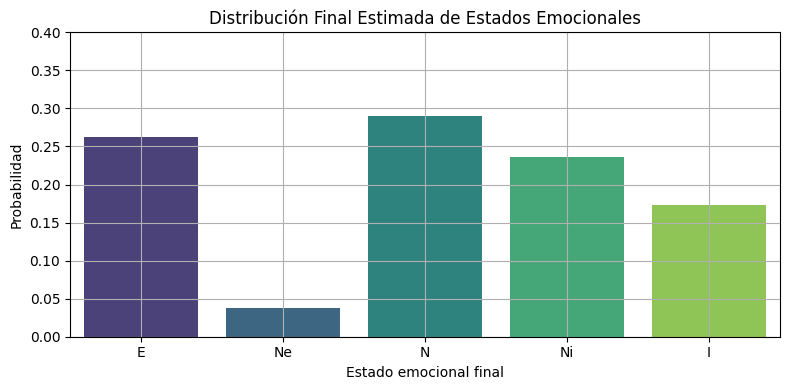

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Leer tu dataset (emociones.csv limpio con ; como separador)
df = pd.read_csv("../../../docs/poblaciones/HMM csv/emocionesGenerales.csv", sep=";")

# Mapa de emociones a números
estado_map = {"E": 0, "Ne": 1, "N": 2, "Ni": 3, "I": 4}
estado_inv_map = {v: k for k, v in estado_map.items()}

# Codificar
df_cod = df.applymap(estado_map.get)



# Crear matriz 5x5
trans_matrix = np.zeros((5, 5), dtype=int)

# Llenar la matriz con datos reales
for _, row in df_cod.iterrows():
    secuencia = row.tolist()
    for i in range(len(secuencia) - 1):
        origen = secuencia[i]
        destino = secuencia[i + 1]
        trans_matrix[origen, destino] += 1

# Normalizar a probabilidades
trans_probs = trans_matrix / trans_matrix.sum(axis=1, keepdims=True)

# Mostrar matriz
df_trans = pd.DataFrame(
    trans_probs,
    index=["E", "Ne", "N", "Ni", "I"],
    columns=["E", "Ne", "N", "Ni", "I"]
)

print("📊 Matriz de transición entre emociones:")
display(df_trans.round(3))




# Simular 1000 trayectorias de longitud 12 (como el número de emociones por persona)
def simular_trayectoria(trans_mat, estado_inicial, pasos=12):
    estado = estado_inicial
    trayectoria = [estado]
    for _ in range(pasos - 1):
        estado = np.random.choice(5, p=trans_mat[estado])
        trayectoria.append(estado)
    return trayectoria

# Ejecutar 1000 simulaciones con estados iniciales aleatorios
simulaciones = [simular_trayectoria(trans_probs, estado_inicial=np.random.choice(5)) for _ in range(1000)]

# Obtener solo los estados finales
finales_simulados = [tray[-1] for tray in simulaciones]

# Calcular distribución final
conteo_final = pd.Series(finales_simulados).value_counts(normalize=True).sort_index()

# Mostrar como texto
print("\n🎯 Distribución emocional final estimada (tras 1000 trayectorias):")
for i, prob in conteo_final.items():
    print(f"{estado_inv_map[i]}: {prob:.3f}")



# Visualizar la distribución final
etiquetas = [estado_inv_map[i] for i in conteo_final.index]
plt.figure(figsize=(8, 4))
sns.barplot(x=etiquetas, y=conteo_final.values, palette="viridis")
plt.title("Distribución Final Estimada de Estados Emocionales")
plt.xlabel("Estado emocional final")
plt.ylabel("Probabilidad")
plt.ylim(0, 0.4)
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\leshi\AppData\Local\Temp\ipykernel_44104\1934216294.py:49: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from current font.
  plt.tight_layout()
C:\Users\leshi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


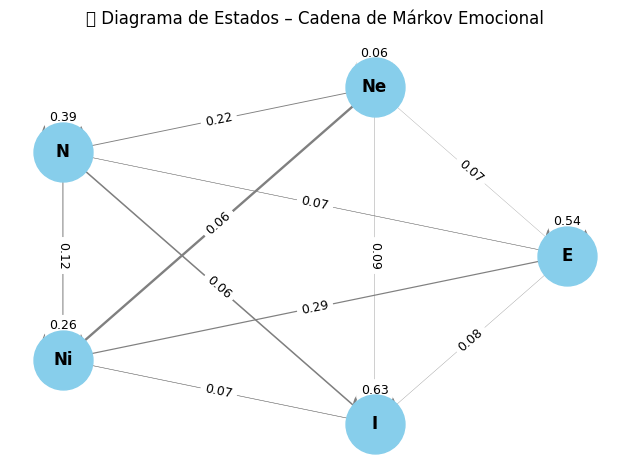

In [28]:
import matplotlib.pyplot as plt
import networkx as nx

# Estados
estados = ["E", "Ne", "N", "Ni", "I"]

# Tu matriz de transición (desde fila → hacia columna)
matriz = [
    [0.541, 0.037, 0.129, 0.290, 0.003],
    [0.066, 0.058, 0.219, 0.569, 0.088],
    [0.065, 0.010, 0.389, 0.167, 0.370],
    [0.047, 0.055, 0.121, 0.263, 0.145],
    [0.077, 0.050, 0.062, 0.066, 0.632],
]

# Crear grafo dirigido
G = nx.DiGraph()

# Añadir nodos
G.add_nodes_from(estados)

# Añadir aristas con pesos
for i, origen in enumerate(estados):
    for j, destino in enumerate(estados):
        prob = matriz[i][j]
        if prob > 0.05:  # Puedes ajustar este umbral para simplificar visual
            G.add_edge(origen, destino, weight=prob)

# Posicionamiento circular o aleatorio
pos = nx.circular_layout(G)

# Dibujar nodos
nx.draw_networkx_nodes(G, pos, node_size=1800, node_color="skyblue")

# Dibujar etiquetas
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")

# Dibujar flechas con pesos
edges = G.edges(data=True)
pesos = [d['weight'] for (_, _, d) in edges]
etiquetas = {(u, v): f"{d['weight']:.2f}" for (u, v, d) in edges}

nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=15, width=[3*p for p in pesos], edge_color="gray")
nx.draw_networkx_edge_labels(G, pos, edge_labels=etiquetas, font_size=9)

# Título y estilo
plt.title("🔁 Diagrama de Estados – Cadena de Márkov Emocional")
plt.axis("off")
plt.tight_layout()
plt.show()
